In [1]:
import ee
import geemap
import pandas as pd
import os

ee.Authenticate()
ee.Initialize(project="gen-lang-client-0412358476")

LONG = 110.4619860
LAT = -5.7972333
AOI = ee.Geometry.Point([LONG, LAT]).buffer(1000)

YEAR_START = 2018
YEAR_END = 2025

CLOUD_FILTER = 20
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

In [2]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index', 'rightField': 'system:index'
        })
    }))

def add_cloud_bands(img):
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')
    return img.addBands(ee.Image([cld_prb, is_cloud]))

def add_shadow_bands(img):
    not_water = img.select('SCL').neq(6)
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH * SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')))
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST * 10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance').mask().rename('cloud_transform'))
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

def add_cld_shdw_mask(img):
    img_cloud = add_cloud_bands(img)
    img_cloud_shadow = add_shadow_bands(img_cloud)
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER * 2 / 20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))
    return img_cloud_shadow.addBands(is_cld_shdw)

def coverage_fraction(img, aoi):
    intersect = img.geometry().intersection(aoi, 1)
    frac = intersect.area(1).divide(aoi.area(1))
    return img.set('aoi_coverage', frac)

print("Functions ready")

Functions ready


In [3]:
results = []
monthly_records = []

for year in range(YEAR_START, YEAR_END + 1):
    start, end = f"{year}-01-01", f"{year}-12-31"
    coll = get_s2_sr_cld_col(AOI, start, end)
    count = coll.size().getInfo()

    if count == 0:
        results.append({
            "year": year, "scene_count": 0,
            "min_coverage": None, "max_coverage": None, "mean_coverage": None,
            "s2a_count": None, "s2b_count": None
        })
        print(f"{year}: 0 scenes — SKIP")
        continue

    coll_cov = coll.map(lambda img: coverage_fraction(img, AOI))
    coverages = coll_cov.aggregate_array('aoi_coverage').getInfo()

    platforms = coll.aggregate_array('SPACECRAFT_NAME').getInfo()
    platform_counts = pd.Series(platforms).value_counts().to_dict()

    timestamps = coll.aggregate_array('system:time_start').getInfo()
    dates = pd.to_datetime(timestamps, unit='ms')
    for m in dates.month.tolist():
        monthly_records.append({"year": year, "month": m})

    results.append({
        "year": year,
        "scene_count": count,
        "min_coverage": round(min(coverages), 3),
        "max_coverage": round(max(coverages), 3),
        "mean_coverage": round(sum(coverages) / len(coverages), 3),
        "s2a_count": platform_counts.get("Sentinel-2A", 0),
        "s2b_count": platform_counts.get("Sentinel-2B", 0),
    })

    print(f"{year}: {count} scenes | coverage min={round(min(coverages),2)} "
          f"max={round(max(coverages),2)} | S2A={platform_counts.get('Sentinel-2A',0)} "
          f"S2B={platform_counts.get('Sentinel-2B',0)}")

df = pd.DataFrame(results)
df_monthly = pd.DataFrame(monthly_records)

2018: 3 scenes | coverage min=1 max=1 | S2A=2 S2B=1
2019: 51 scenes | coverage min=1 max=1 | S2A=28 S2B=23
2020: 29 scenes | coverage min=1 max=1 | S2A=12 S2B=17
2021: 32 scenes | coverage min=1 max=1 | S2A=16 S2B=16
2022: 11 scenes | coverage min=1 max=1 | S2A=2 S2B=9
2023: 48 scenes | coverage min=1 max=1 | S2A=26 S2B=22
2024: 34 scenes | coverage min=1 max=1 | S2A=19 S2B=15
2025: 24 scenes | coverage min=1 max=1 | S2A=3 S2B=10


In [4]:
pivot = df_monthly.pivot_table(index='year', columns='month', aggfunc=len, fill_value=0)
pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2018,0,0,0,0,0,0,2,1,0,0,0,0
2019,0,1,0,1,3,5,11,9,11,5,5,0
2020,2,0,2,0,1,2,7,9,4,0,2,0
2021,0,1,0,6,3,2,7,5,5,3,0,0
2022,0,0,0,0,2,0,3,4,2,0,0,0
2023,1,0,2,0,8,5,8,6,8,6,3,1
2024,0,2,1,0,3,2,7,7,8,4,0,0
2025,0,0,1,1,2,4,8,3,3,2,0,0


In [5]:
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/sentinel2_scene_availability.csv", index=False)
df_monthly.to_csv("outputs/sentinel2_monthly_distribution.csv", index=False)
pivot.to_csv("outputs/sentinel2_monthly_pivot.csv")
print("Semua output tersimpan di outputs/")

Semua output tersimpan di outputs/


In [6]:
sample_year = 2022
sample_col = get_s2_sr_cld_col(AOI, f"{sample_year}-01-01", f"{sample_year}-12-31")
sample_disp = sample_col.map(add_cld_shdw_mask)
img = sample_disp.mosaic()

Map = geemap.Map(center=[LAT, LONG], zoom=14)
Map.addLayer(img, {'bands': ['B4','B3','B2'], 'min':0, 'max':2500, 'gamma':1.1}, 'S2 image')
Map.addLayer(img.select('cloudmask').selfMask(), {'palette':'orange'}, 'cloudmask')
Map.addLayer(AOI, {"color": "red"}, "AOI Mrican")
Map.addLayerControl()
Map

Map(center=[-5.7972333, 110.461986], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

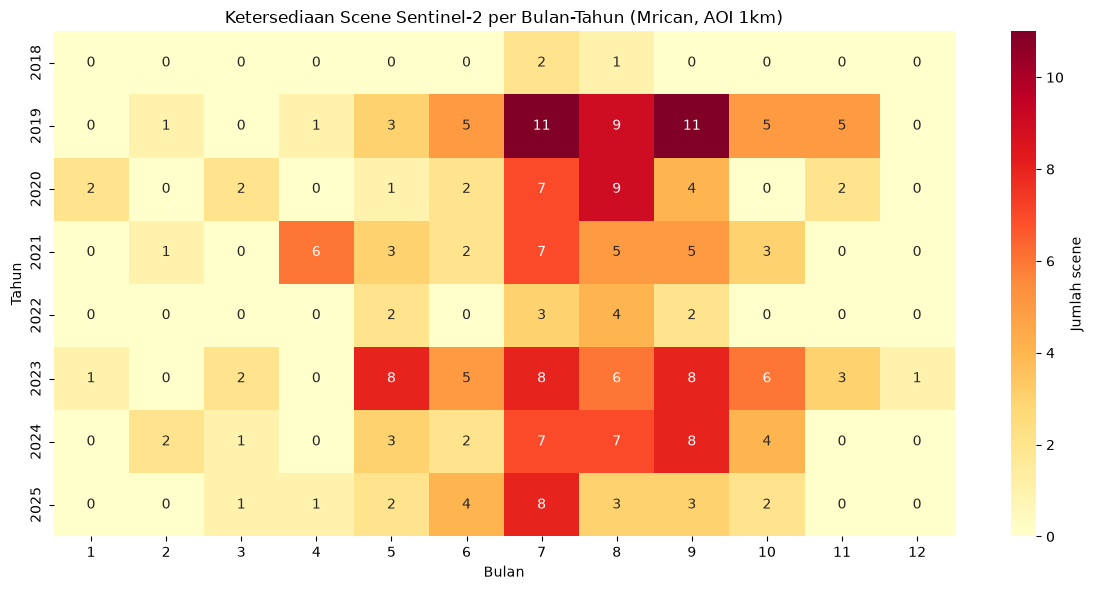

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Jumlah scene'})
plt.title('Ketersediaan Scene Sentinel-2 per Bulan-Tahun (Mrican, AOI 1km)')
plt.xlabel('Bulan')
plt.ylabel('Tahun')
plt.tight_layout()
plt.savefig('outputs/heatmap_scene_availability.png', dpi=150)
plt.show()

In [8]:
scene_ids = []
for year in range(YEAR_START, YEAR_END + 1):
    start, end = f"{year}-01-01", f"{year}-12-31"
    coll = get_s2_sr_cld_col(AOI, start, end)
    ids = coll.aggregate_array('system:index').getInfo()
    dates = coll.aggregate_array('system:time_start').getInfo()
    for sid, ts in zip(ids, dates):
        scene_ids.append({"year": year, "scene_id": sid, "timestamp": ts})

df_scenes = pd.DataFrame(scene_ids)
df_scenes.to_csv("outputs/sentinel2_scene_ids.csv", index=False)
df_scenes

,year,scene_id,timestamp
0,2018,20180716T024551_20180716T030223_T49MDP,1531710574192
1,2018,20180728T023549_20180728T025431_T49MDP,1532746775072
2,2018,20180815T024551_20180815T025247_T49MDP,1534302572295
3,2019,20190226T024659_20190226T030922_T49MDP,1551150572000
4,2019,20190404T023549_20190404T025538_T49MDP,1554346781000
...,...,...,...
227,2025,20250904T023611_20250904T025918_T49MDP,1756954795477
228,2025,20250907T024601_20250907T030918_T49MDP,1757214589317
229,2025,20250927T024541_20250927T030709_T49MDP,1758942588494
230,2025,20251009T023529_20251009T025419_T49MDP,1759978776383
